# Module 01: Jupyter Notebook Assignment

## Name: 

### Part I: Instructions

In this part of the assignment, your task is to create a one-dimensional random walk model similar to the one in [the example notebook](./mod01-PythonIntro-1.ipynb) with the following parameters:

* `Nt` = 200
* `mu_x` = 1.5
* `s_x` = 2.1
* `min_x` = 1.25

Where `min_x` is a new parameter that is the _minimum step size_ at each step in the random walk. When you calculate the step size at each step, you will only accept values that are larger than `min_x` by using a `while` loop to keep generating step sizes until the step size exceeds `min_x`. Do this for `Nx` = 1,000 random walkers. 

___Deliverables:___ 

1. Code to create the random walk with comments
2. Reproduce the 2 figures in section 5.1 and 5.2 of the example notebook (__Note__: you will have to adjust the `bins` and `range` parameters provided to histogram). 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Nt = 200 # number of steps/units of time
Nx = 1000 # number of walkers 

mu_x = 1.5 #mean
s_x = 2.1 #standard deviation
min_x = 1.25 #minimum step size


In [15]:
#need to tell our model how many steps we are stepping, how many walkers are walking!
X = np.zeros((Nt,Nx)) #need double parentheses here because Nt,Nx is making a matrix instead of a unit vector

#for loop to iterate our walker through all of their steps
    
for i in np.arange(Nt): #for the ith step
    for j in np.arange(Nx): #for the jth walker
            while True:
                n_i = s_x*np.random.randn() + mu_x #this is random draw from a normal distribution 
                if n_i >= min_x: #guarantee our minimum step size
                    break #break out of the loop to proceed
            if(i==0): #we need to set the if condition so that we can record our starting condition and add steps
                X[i,j] = 0 + n_i #the first step from our origin (0,0)
            else:
                X[i,j] = X[i-1,j] + n_i #look at the previous index position and add n_i to that

Text(0, 0.5, 'Distance Traveled [m]')

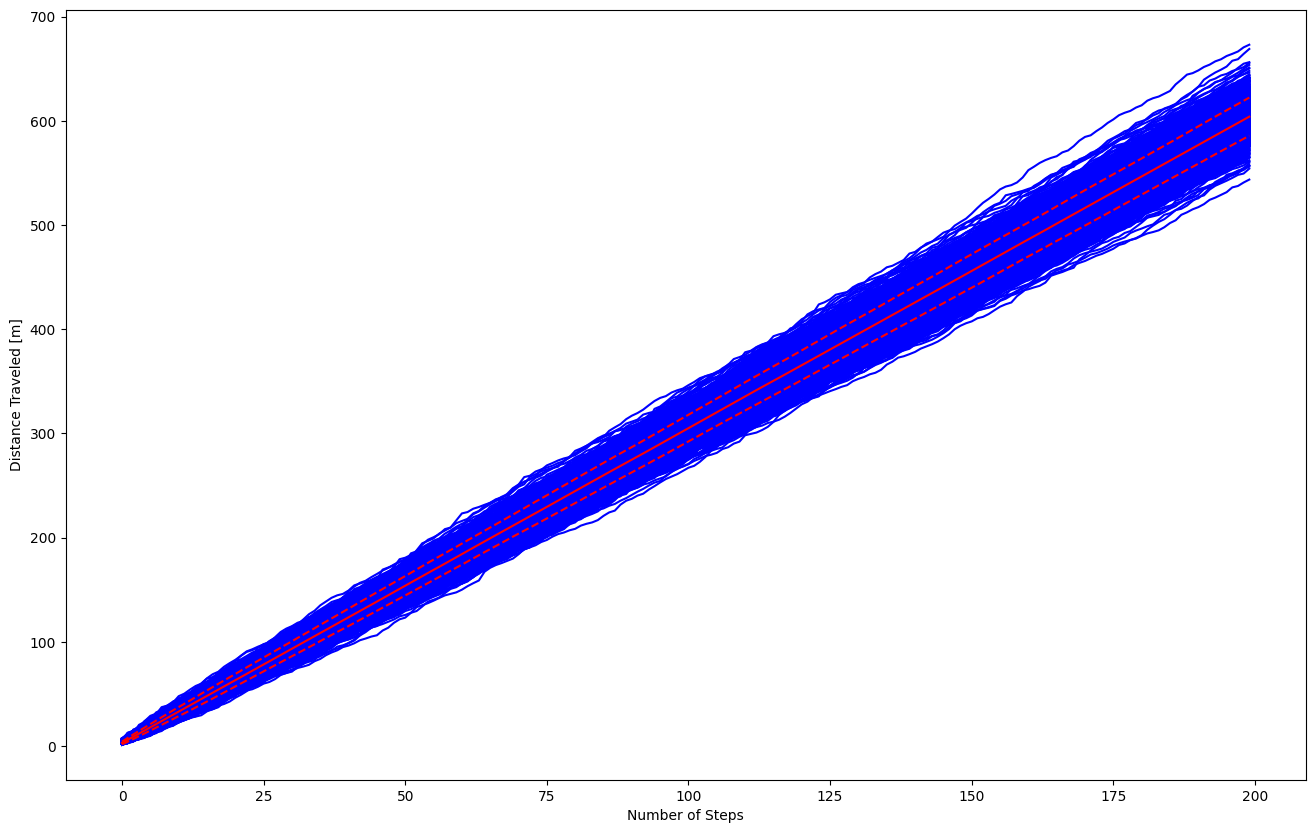

In [ ]:
mean_X = np.mean(X, axis = 1) #average distance traveled/step
std_X = np.std(X, axis = 1) #one standard deviation +- the mean 

plt.figure(figsize=(16,10)) #make 16 wide 10 tall figure

plt.plot(np.arange(Nt),X,'b-') #all walkers at Nt(i) steps
plt.plot(np.arange(Nt),mean_X,'r-') #mean of all walkers
plt.plot(np.arange(Nt),mean_X + std_X, 'r--') #+1 sd 
plt.plot(np.arange(Nt),mean_X - std_X, 'r--') #-1 sd
plt.xlabel('Number of Steps') 
plt.ylabel('Distance Traveled [m]') 

Text(0, 0.5, 'Frequency [-]')

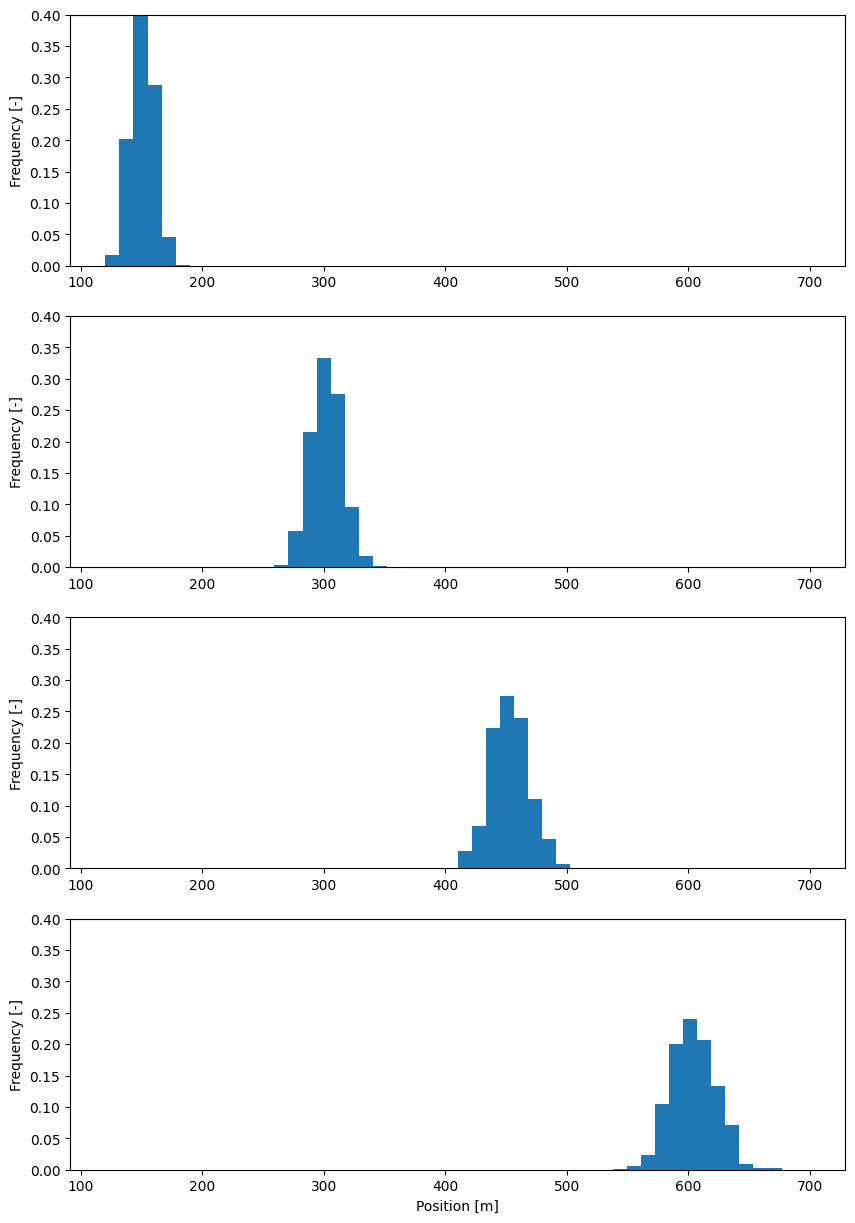

In [ ]:
x_50, be_50 = np.histogram(X[49,:], bins=50, range=(120.0,700))
x_100, be_100 = np.histogram(X[99,:], bins=50, range=(120.0,700))
x_150, be_150 = np.histogram(X[149,:], bins=50, range=(120.0,700))
x_200, be_200 = np.histogram(X[-1,:], bins=50, range=(120.0,700))

plt.figure(figsize=(10,15))
plt.subplot(4,1,1)
plt.bar((be_50[1:]+be_50[:-1])/2, (x_50/np.sum(x_50)), width=(be_50[1]-be_50[0])) #have to center your bins and determine how wide each one is: (first + last)/2 gets us bin height and width is set by index 1 - index 0 
plt.ylim((0.0,0.4))
plt.ylabel('Frequency [-]')

plt.subplot(4,1,2)
plt.bar((be_100[1:]+be_100[:-1])/2, (x_100/np.sum(x_100)), width=(be_100[1]-be_100[0]))
plt.ylim((0.0,0.4))
plt.ylabel('Frequency [-]')

plt.subplot(4,1,3)
plt.bar((be_150[1:]+be_150[:-1])/2, (x_150/np.sum(x_150)), width=(be_150[1]-be_150[0]))
plt.ylim((0.0,0.4))
plt.ylabel('Frequency [-]')

plt.subplot(4,1,4)
plt.bar((be_200[1:]+be_200[:-1])/2, (x_200/np.sum(x_200)), width=(be_200[1]-be_200[0]))
plt.ylim((0.0,0.4))
plt.xlabel('Position [m]')
plt.ylabel('Frequency [-]')


### Part II: Instructions

In this part of the assignment, your task is to create a __two-dimensional__ random walk model. The 2-D random walk is just an extension of the 1-D random walk into a second dimension. Assume that at each step in the random walk, the step size in the x- and y-directions are _independent_ of one another. That is, you do not need to know anything about the step size in the x-direction to calculate the step size in the y-direction and vice versa. Use the following parameters:

* Nt = 300
* Nx = 3
* mu_x = 0.5
* s_x = 1.5
* mu_y = 5.0
* s_y = 2.5

Where `mu_y` and `s_y` are, respectively, the average and standard deviation of the step size in the y-direction.

___Deliverables___

1. Code to create the random walk with comments
2. Plot the position of all three random walkers at each step of their respective random walks on the ___same plot___.

In [23]:
Nt = 300
Nx = 3

mu_x = 0.5
s_x = 1.5
mu_y = 5.0
s_y = 2.5


In [ ]:
#need to tell our model how many steps we are stepping, how many walkers are walking!
X2d = np.zeros((Nt,Nx,2)) #need double parentheses here because Nt,Nx,2 is making a 3d matrix (# of steps * # of walkers * 2)
# I prefer 3D matrix of size Nt x Nx x 2 over two 2D matrices of size Nt x Nx
    
X2d[i, j, 0]   # x position of walker j at timestep i
X2d[i, j, 1]   # y position of walker j at timestep i

for i in np.arange(Nt): #for the ith step
    for j in np.arange(Nx): #for the jth walker
            n_x = s_x*np.random.randn() + mu_x #this is random draw from a normal distribution 
            n_y = s_y*np.random.randn() + mu_y
            if(i==0): #we need to set the if condition so that we can record our starting condition and add steps
                X2d[i,j,0] = 0 + n_x #the first step from our origin (0,0)
                X2d[i,j,1] = 0 + n_y #the first step from our origin (0,0)
            else:
                X2d[i,j,0] = X2d[i-1,j,0] + n_x #look at the previous index position and add n_i to that
                X2d[i,j,1] = X2d[i-1,j,1] + n_y #look at the previous index position and add n_i to that

Text(0.5, 0, 'Time')

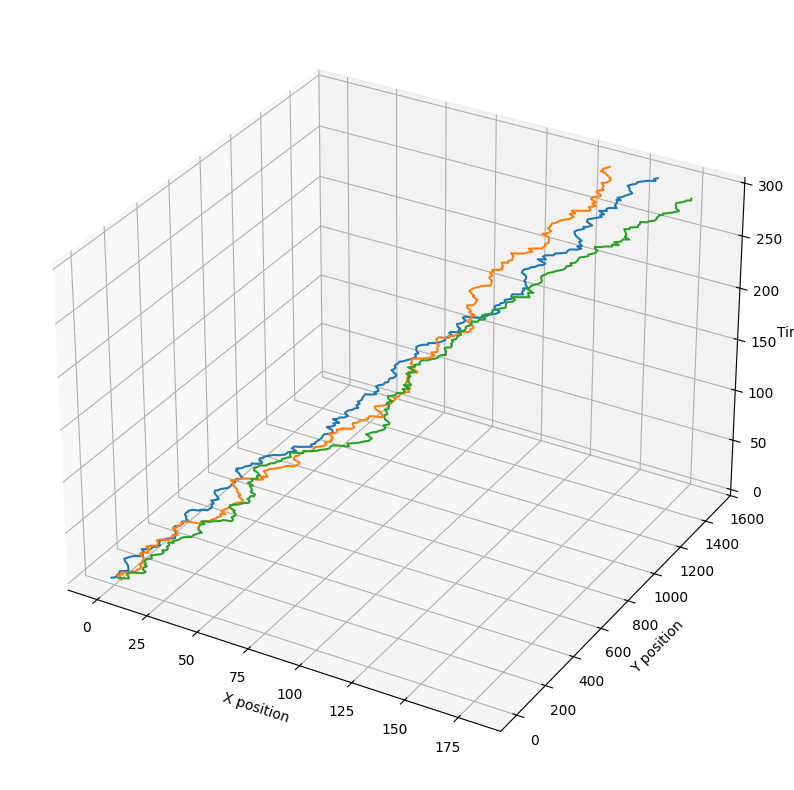

In [ ]:
fig = plt.figure(figsize=(16, 10)) # make the figure
ax = fig.add_subplot(projection='3d') #3D that sh*t!
for j in range(Nx): # we need the position of the jth walker in the two directions
    ax.plot( #because we have a 3D matrix, we can look at Nt[i] per walker j per axis
        X2d[:, j, 0],      # x position
        X2d[:, j, 1],      # y position
        np.arange(Nt)      # timestep
    )
ax.set_xlabel('X position')
ax.set_ylabel('Y position')
ax.set_zlabel('Time')
